# Zadanie obowiązkowe [0-10] pkt

- Zapoznaj się z analizą zbioru [twarzy OLivetti](https://scikit-learn.org/stable/auto_examples/decomposition/plot_faces_decomposition.html)
- Zapoznaj się z ze zbiorem [klasyfikacji cyfr](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html)

1. [0-1 pkt] Załaduj zbiór cyfr, a następnie wyświetl pierwsze 6 (2 wiersze, 3 kolumny) elementów zbioru za pomocą funkcji `plot_gallery()` (zob. pierwszy link)
1. [0-0.5 pkt] Podziel zbiór na treningowy i walidacyjny (czy zbiór jest zbalansowany i wystarczy zwykły podział losowy?). Pamiętaj, że skalowanie cech jak i dostrojenie redukcji wymiarowości (metoda `fit`) przeprowadzamy na zbiorze treningowym!
1. [0-2.5 pkt] Dokonaj transformacji zbioru `digits` przy użyciu (w każdym przypadku wyrysuj kilka przykładowych elementów zbioru):
   1. PCA
   2. [NMF](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html) (jaki będzie input?)
   3. [Factor Analysis](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.FactorAnalysis.html)
   4. [Jądrowy PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html) (przy użyciu przynajmniej trzech nieliniowych jąder)
2. [0-1.5 pkt] Wytrenuj regresję logistyczną na zbiorze oryginalnym (model *baseline*) oraz przetransformowanym za pomocą technik z punktu 3.
1. [0-1.5 pkt] Sporządź analizę porównawczą wyników zarówno dla zbioru treningowego jak i walidacyjnego. Wyrysuj macierz pomyłek oraz metryki zbiorcze
3. [0-1 pkt] Wybierz $n=32, 16, 8, 4, 2$ dominujące cechy w każdej metodzie i wykonaj analizę w pkt. 5.
1. [0-1 pkt] Skomentuj uzyskane wyniki. Czy redukcja wymiarowości jest optymalnym rozwiązaniem w przypadku tego zbioru? Jeśli tak, to która? Jeśli żadna, to dlaczego?
2. [0-1 pkt] Zaproponuj usprawnienie metodologii wyżej (np. inną technikę selekcji cech)

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import pandas as pd

# 1. Załaduj zbiór cyfr, a następnie wyświetl pierwsze 6 elementów zbioru.

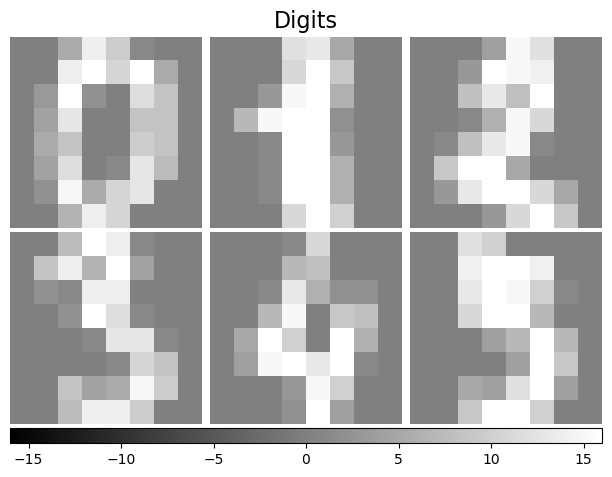

In [2]:
digits = load_digits()

n_row, n_col = 2, 3
n_components = n_row * n_col
image_shape = digits.images[0].shape

def plot_gallery(title, images, n_col=n_col, n_row=n_row, cmap=plt.cm.gray):
    fig, axs = plt.subplots(
        nrows=n_row,
        ncols=n_col,
        figsize=(2.0 * n_col, 2.3 * n_row),
        facecolor="white",
        constrained_layout=True,
    )
    fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.02, hspace=0, wspace=0)
    fig.set_edgecolor("black")
    fig.suptitle(title, size=16)
    for ax, vec in zip(axs.flat, images):
        vmax = max(vec.max(), -vec.min())
        im = ax.imshow(
            vec.reshape(image_shape),
            cmap=cmap,
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
        )
        ax.axis("off")

    fig.colorbar(im, ax=axs, orientation="horizontal", shrink=0.99, aspect=40, pad=0.01)
    plt.show()

plot_gallery("Digits", digits.images[:n_components], n_col=n_col, n_row=n_row)

# 2. Podziel zbiór na treningowy i walidacyjny.

In [3]:
from sklearn.model_selection import train_test_split

class_distribution = pd.Series(digits.target).value_counts().sort_index()
print("Class distribution:\n", class_distribution)

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=0, stratify=digits.target # stratify zapewni równomierny podział klas
)

Class distribution:
 0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


# 3. Dokonaj transformacji zbioru `digits` przy użyciu [...]

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# PCA, FA, KPCA
scaler_standard = StandardScaler()
X_train_std = scaler_standard.fit_transform(X_train)

# NMF
scaler_minmax = MinMaxScaler()
X_train_nmf = scaler_minmax.fit_transform(X_train)

In [5]:
def plot_gallery(images, titles, h, w, n_row=2, n_col=3):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        img = images[i].reshape((h, w))
        plt.imshow(img, cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())
    plt.show()

### 3.1. PCA

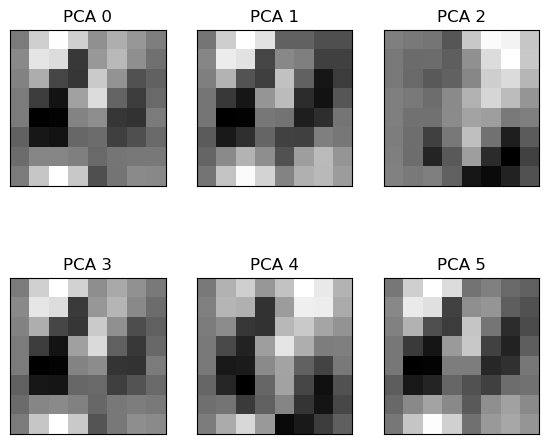

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_train_std)

plot_gallery(pca.inverse_transform(X_pca)[:6], [f'PCA {i}' for i in range(6)], 8, 8)

### 3.2. NMF

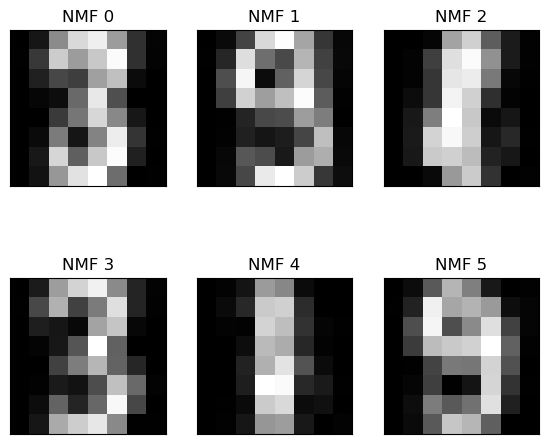

In [7]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=16, random_state=0) # 16 komponentów
X_nmf = nmf.fit_transform(X_train_nmf)

plot_gallery(nmf.inverse_transform(X_nmf)[:6], [f'NMF {i}' for i in range(6)], 8, 8)

### 3.2. Factor Analysis

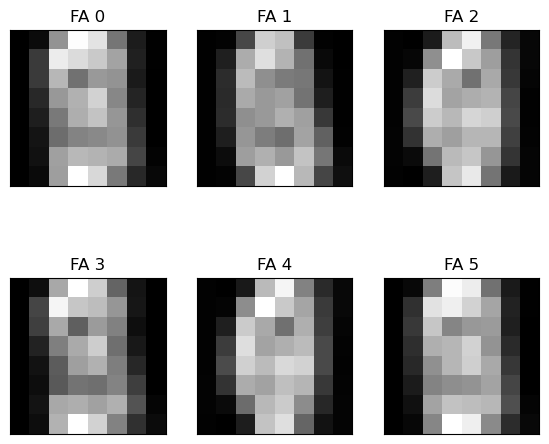

In [8]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=2, random_state=0)
X_fa = fa.fit_transform(X_train_std)

# Rekonstrukcja
X_inv_fa_std = X_fa @ fa.components_
X_inv_fa = scaler_standard.inverse_transform(X_inv_fa_std)

plot_gallery(X_inv_fa[:6], [f'FA {i}' for i in range(6)], 8, 8)

### 3.3 Jądrowy PCA

Kernel PCA (poly)


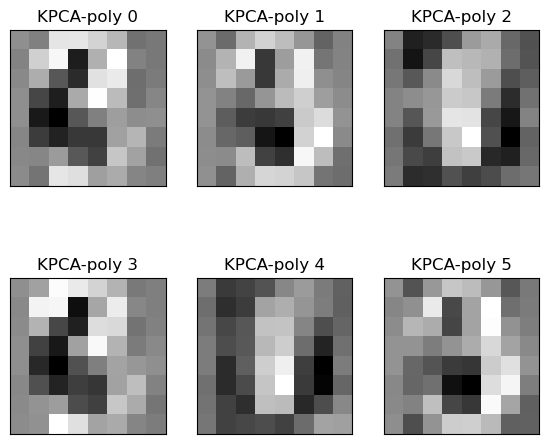

Kernel PCA (rbf)


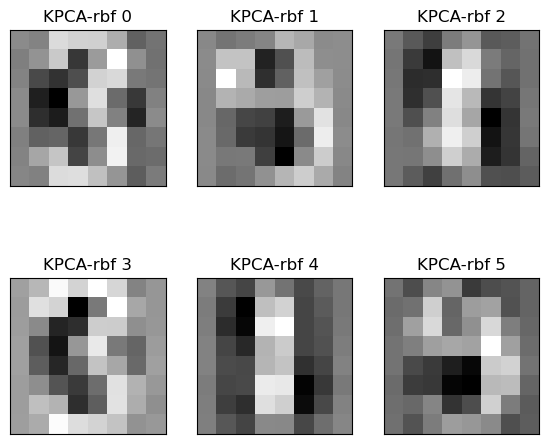

Kernel PCA (sigmoid)


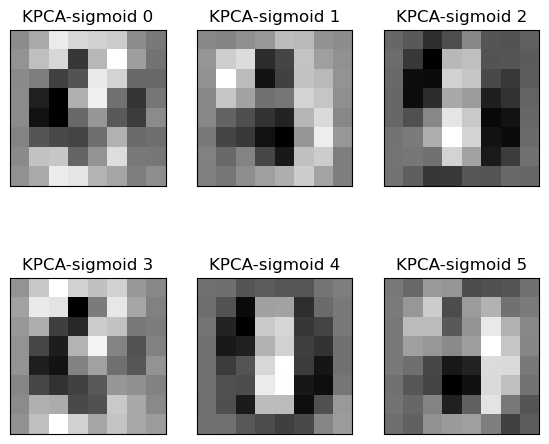

In [9]:
from sklearn.decomposition import KernelPCA

for kernel in ['poly', 'rbf', 'sigmoid']:
    print(f'Kernel PCA ({kernel})')

    kpca = KernelPCA(
        n_components=16,
        kernel=kernel,
        fit_inverse_transform=True,
        gamma=0.03,
        degree=3,
        random_state=0
    )
    
    X_kpca = kpca.fit_transform(X_train_std)
    X_inv_kpca = kpca.inverse_transform(X_kpca)

    plot_gallery(X_inv_kpca[:6], [f'KPCA-{kernel} {i}' for i in range(6)], 8, 8)

# 4. Wytrenuj regresję logistyczną na zbiorze oryginalnym (model *baseline*) oraz przetransformowanym za pomocą technik z punktu 3.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, NMF, FactorAnalysis, KernelPCA
from sklearn.metrics import accuracy_score

In [11]:
# Skalowanie
scaler_standard = StandardScaler()
X_train_std = scaler_standard.fit_transform(X_train)
X_test_std = scaler_standard.transform(X_test)

scaler_minmax = MinMaxScaler()
X_train_nmf = scaler_minmax.fit_transform(X_train)
X_test_nmf = scaler_minmax.transform(X_test)

In [12]:
# Baseline
clf_base = LogisticRegression(random_state=0)
clf_base.fit(X_train, y_train)
acc_base = accuracy_score(y_test, clf_base.predict(X_test))
print(f'Baseline (oryginalne dane): {acc_base:.3f}')

# PCA
pca = PCA(n_components=16, random_state=0)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

clf_pca = LogisticRegression(random_state=0)
clf_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, clf_pca.predict(X_test_pca))
print(f'PCA (16 komponentów): {acc_pca:.3f}')

# NMF
nmf = NMF(n_components=16, random_state=0)
X_train_nmf_red = nmf.fit_transform(X_train_nmf)
X_test_nmf_red = nmf.transform(X_test_nmf)

clf_nmf = LogisticRegression(random_state=0)
clf_nmf.fit(X_train_nmf_red, y_train)
acc_nmf = accuracy_score(y_test, clf_nmf.predict(X_test_nmf_red))
print(f'NMF (16 komponentów): {acc_nmf:.3f}')

# FA
fa = FactorAnalysis(n_components=16, random_state=0)
X_train_fa = fa.fit_transform(X_train_std)
X_test_fa = fa.transform(X_test_std)

clf_fa = LogisticRegression(random_state=0)
clf_fa.fit(X_train_fa, y_train)
acc_fa = accuracy_score(y_test, clf_fa.predict(X_test_fa))
print(f'Factor Analysis (16 komp.): {acc_fa:.3f}')

# Kernel PCA
for kernel in ['rbf', 'sigmoid', 'poly']:
    kpca = KernelPCA(
        n_components=16,
        kernel=kernel,
        gamma=0.03,
        degree=3,
        fit_inverse_transform=False
    )
    X_train_kpca = kpca.fit_transform(X_train_std)
    X_test_kpca = kpca.transform(X_test_std)

    clf_kpca = LogisticRegression(max_iter=1000, random_state=0)
    clf_kpca.fit(X_train_kpca, y_train)
    acc_kpca = accuracy_score(y_test, clf_kpca.predict(X_test_kpca))
    print(f'Kernel PCA ({kernel}): {acc_kpca:.3f}')

c:\Users\Jakub\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline (oryginalne dane): 0.961
PCA (16 komponentów): 0.939
NMF (16 komponentów): 0.789
Factor Analysis (16 komp.): 0.939
Kernel PCA (rbf): 0.897
Kernel PCA (sigmoid): 0.942
Kernel PCA (poly): 0.733


# 5. Sporządź analizę porównawczą wyników zarówno dla zbioru treningowego jak i walidacyjnego. Wyrysuj macierz pomyłek oraz metryki zbiorcze.

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Dict for storing models and their data
models = {
    'Baseline': (clf_base, X_train, X_test),
    'PCA': (clf_pca, X_train_pca, X_test_pca),
    'NMF': (clf_nmf, X_train_nmf_red, X_test_nmf_red),
    'FA': (clf_fa, X_train_fa, X_test_fa),
}

for kernel in ['rbf', 'sigmoid', 'poly']:
    name = f'KPCA-{kernel}'
    kpca = KernelPCA(n_components=16, kernel=kernel, gamma=0.03, degree=3)
    X_train_kpca = kpca.fit_transform(X_train_std) 
    X_test_kpca = kpca.transform(X_test_std)
    clf = LogisticRegression(random_state=0)
    clf.fit(X_train_kpca, y_train)
    models[name] = (clf, X_train_kpca, X_test_kpca)


=== Baseline ===
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.85      0.97      0.91        36
           2       1.00      0.97      0.99        35
           3       0.97      1.00      0.99        37
           4       1.00      0.94      0.97        36
           5       0.97      0.95      0.96        37
           6       0.97      0.97      0.97        36
           7       0.97      0.97      0.97        36
           8       0.94      0.86      0.90        35
           9       0.95      0.97      0.96        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



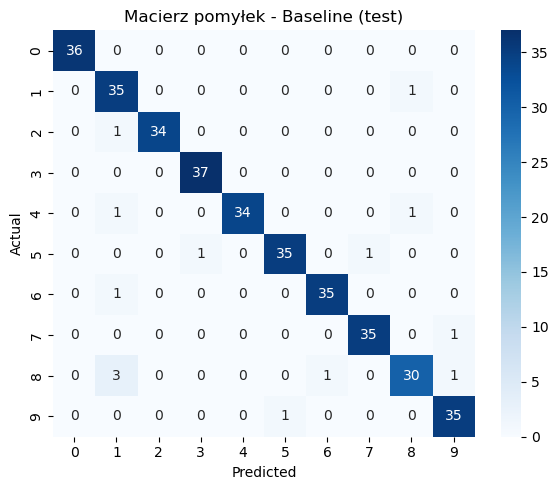

Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       142
           1       1.00      1.00      1.00       146
           2       1.00      1.00      1.00       142
           3       1.00      1.00      1.00       146
           4       1.00      1.00      1.00       145
           5       1.00      1.00      1.00       145
           6       1.00      1.00      1.00       145
           7       1.00      1.00      1.00       143
           8       1.00      1.00      1.00       139
           9       1.00      1.00      1.00       144

    accuracy                           1.00      1437
   macro avg       1.00      1.00      1.00      1437
weighted avg       1.00      1.00      1.00      1437



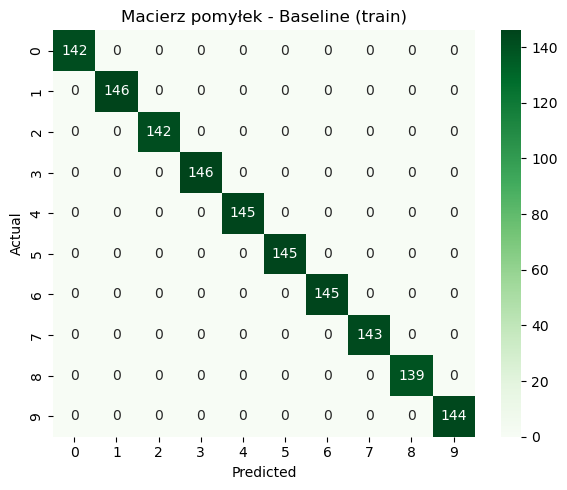


=== PCA ===
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.80      0.89      0.84        36
           2       0.97      0.97      0.97        35
           3       0.94      0.92      0.93        37
           4       0.94      0.94      0.94        36
           5       0.92      0.97      0.95        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.83      0.88        35
           9       0.92      0.92      0.92        36

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



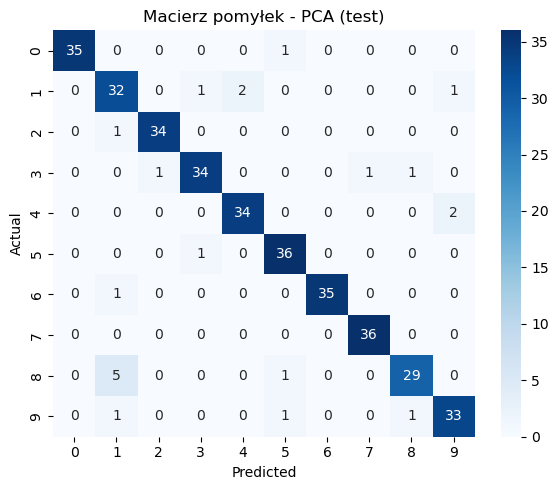

Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       142
           1       0.93      0.96      0.95       146
           2       0.99      1.00      0.99       142
           3       0.97      0.94      0.95       146
           4       0.99      0.98      0.99       145
           5       0.97      0.97      0.97       145
           6       0.99      0.98      0.98       145
           7       0.99      0.99      0.99       143
           8       0.91      0.89      0.90       139
           9       0.90      0.94      0.92       144

    accuracy                           0.96      1437
   macro avg       0.96      0.96      0.96      1437
weighted avg       0.96      0.96      0.96      1437



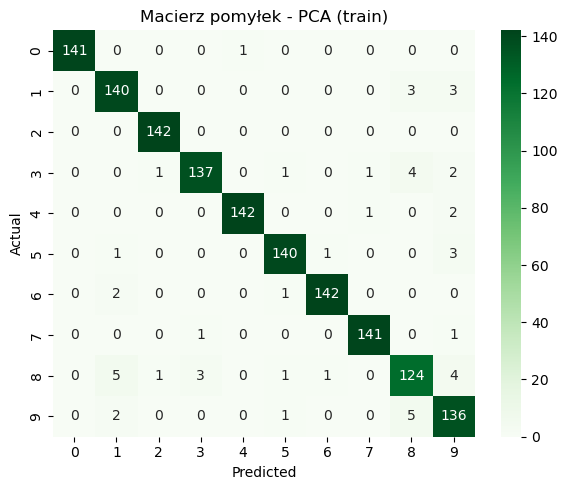


=== NMF ===
Test Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93        36
           1       0.68      0.58      0.63        36
           2       0.73      0.69      0.71        35
           3       0.91      0.86      0.89        37
           4       0.81      0.83      0.82        36
           5       0.74      0.92      0.82        37
           6       0.83      0.97      0.90        36
           7       0.88      0.78      0.82        36
           8       0.71      0.43      0.54        35
           9       0.68      0.83      0.75        36

    accuracy                           0.79       360
   macro avg       0.79      0.79      0.78       360
weighted avg       0.79      0.79      0.78       360



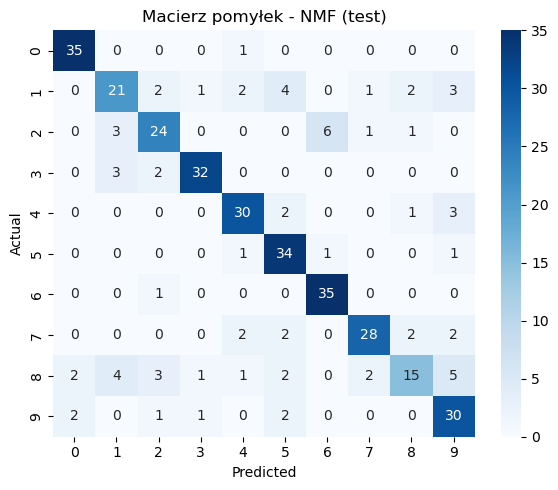

Train Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       142
           1       0.82      0.50      0.62       146
           2       0.72      0.76      0.74       142
           3       0.74      0.79      0.76       146
           4       0.85      0.88      0.87       145
           5       0.78      0.90      0.84       145
           6       0.87      0.97      0.92       145
           7       0.86      0.83      0.84       143
           8       0.74      0.58      0.65       139
           9       0.75      0.85      0.80       144

    accuracy                           0.80      1437
   macro avg       0.80      0.80      0.80      1437
weighted avg       0.80      0.80      0.80      1437



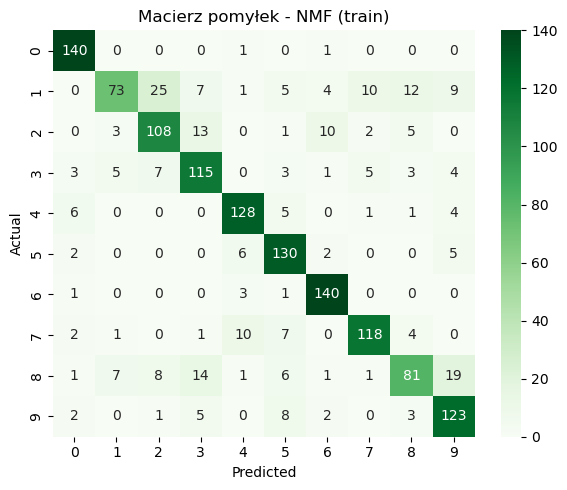


=== FA ===
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.83      0.97      0.90        36
           2       0.92      0.94      0.93        35
           3       1.00      0.89      0.94        37
           4       0.97      0.92      0.94        36
           5       0.95      0.97      0.96        37
           6       0.97      0.97      0.97        36
           7       0.92      0.97      0.95        36
           8       0.90      0.80      0.85        35
           9       0.94      0.94      0.94        36

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360



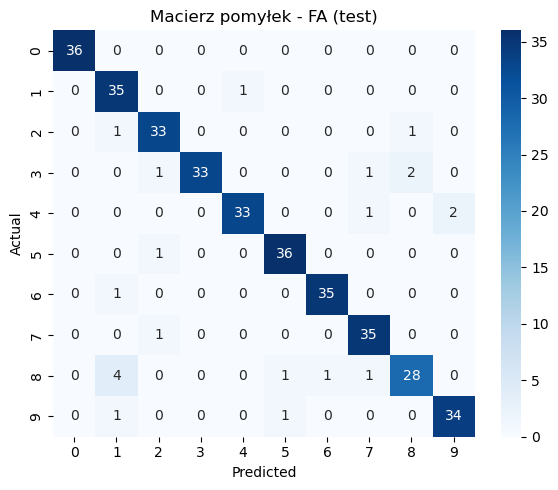

Train Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       142
           1       0.93      0.95      0.94       146
           2       0.99      0.99      0.99       142
           3       0.98      0.94      0.96       146
           4       1.00      0.98      0.99       145
           5       0.97      0.98      0.97       145
           6       0.99      0.98      0.98       145
           7       0.98      0.98      0.98       143
           8       0.93      0.92      0.93       139
           9       0.93      0.96      0.94       144

    accuracy                           0.97      1437
   macro avg       0.97      0.97      0.97      1437
weighted avg       0.97      0.97      0.97      1437



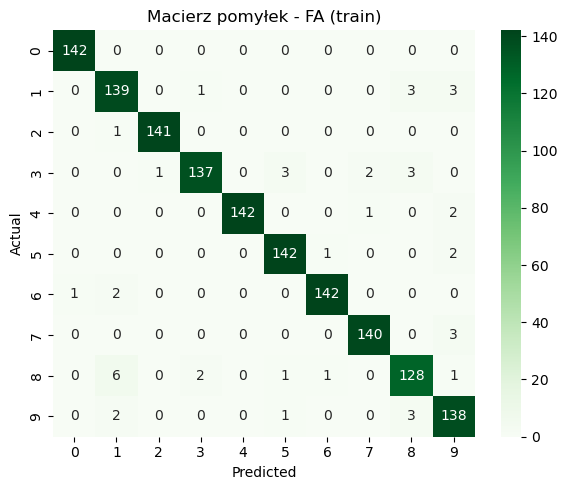


=== KPCA-rbf ===
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.75      0.92      0.82        36
           2       0.97      0.83      0.89        35
           3       0.94      0.89      0.92        37
           4       0.87      0.92      0.89        36
           5       0.92      0.89      0.90        37
           6       1.00      0.94      0.97        36
           7       0.87      0.94      0.91        36
           8       0.84      0.77      0.81        35
           9       0.86      0.86      0.86        36

    accuracy                           0.90       360
   macro avg       0.90      0.90      0.90       360
weighted avg       0.90      0.90      0.90       360



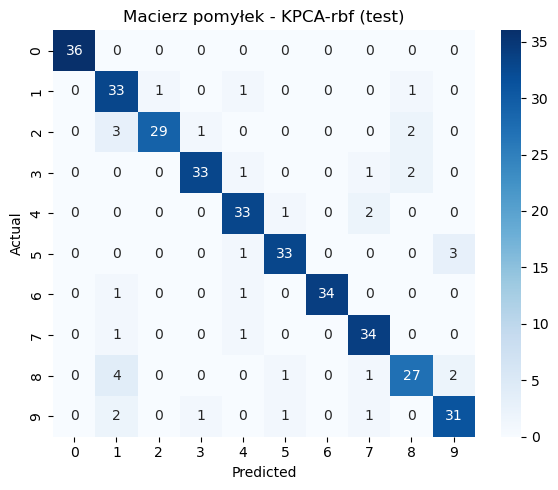

Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       142
           1       0.84      0.91      0.88       146
           2       0.88      0.89      0.89       142
           3       0.96      0.86      0.91       146
           4       0.90      0.98      0.94       145
           5       0.94      0.93      0.93       145
           6       0.99      0.92      0.95       145
           7       0.90      0.93      0.92       143
           8       0.85      0.84      0.85       139
           9       0.87      0.86      0.87       144

    accuracy                           0.91      1437
   macro avg       0.91      0.91      0.91      1437
weighted avg       0.91      0.91      0.91      1437



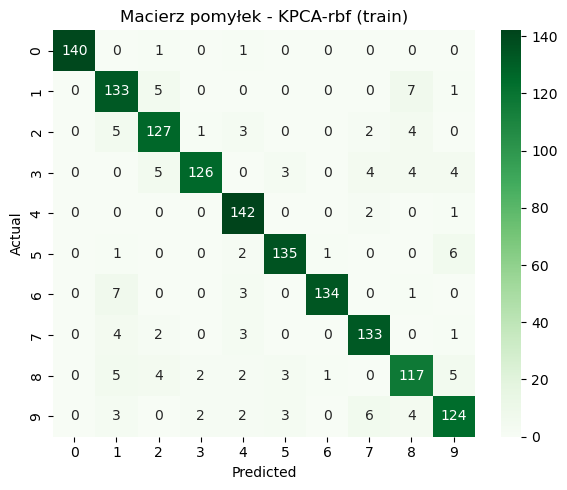


=== KPCA-sigmoid ===
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.75      0.92      0.82        36
           2       1.00      0.94      0.97        35
           3       1.00      0.95      0.97        37
           4       1.00      0.92      0.96        36
           5       0.93      1.00      0.96        37
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.90      0.80      0.85        35
           9       0.94      0.92      0.93        36

    accuracy                           0.94       360
   macro avg       0.95      0.94      0.94       360
weighted avg       0.95      0.94      0.94       360



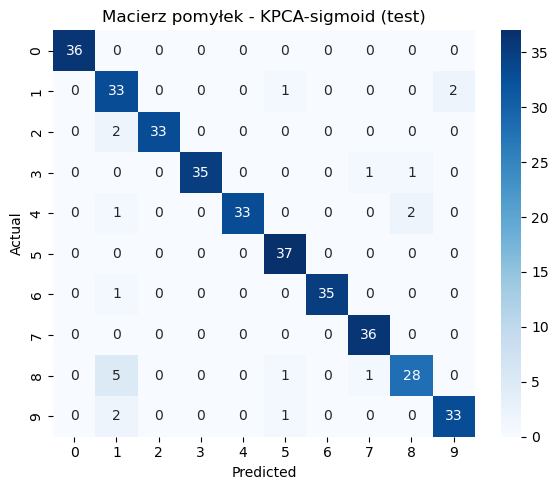

Train Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       142
           1       0.86      0.86      0.86       146
           2       0.97      0.97      0.97       142
           3       0.96      0.91      0.94       146
           4       0.97      0.97      0.97       145
           5       0.95      0.96      0.96       145
           6       0.97      0.97      0.97       145
           7       0.97      0.98      0.97       143
           8       0.88      0.87      0.87       139
           9       0.86      0.91      0.89       144

    accuracy                           0.94      1437
   macro avg       0.94      0.94      0.94      1437
weighted avg       0.94      0.94      0.94      1437



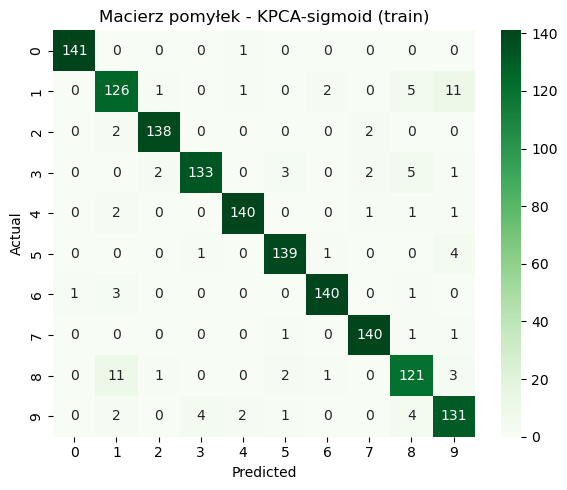


=== KPCA-poly ===
Test Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92        36
           1       0.58      0.92      0.71        36
           2       0.90      0.74      0.81        35
           3       0.56      0.65      0.60        37
           4       0.97      0.89      0.93        36
           5       0.79      0.62      0.70        37
           6       1.00      0.92      0.96        36
           7       0.72      0.81      0.76        36
           8       0.55      0.31      0.40        35
           9       0.50      0.53      0.51        36

    accuracy                           0.73       360
   macro avg       0.75      0.73      0.73       360
weighted avg       0.75      0.73      0.73       360



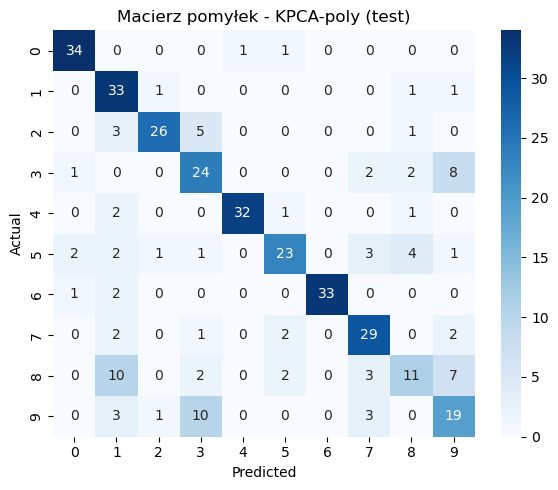

Train Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       142
           1       0.74      0.84      0.79       146
           2       0.87      0.73      0.79       142
           3       0.63      0.70      0.66       146
           4       0.97      0.98      0.97       145
           5       0.71      0.70      0.71       145
           6       0.99      0.97      0.98       145
           7       0.74      0.76      0.75       143
           8       0.58      0.47      0.52       139
           9       0.57      0.60      0.58       144

    accuracy                           0.77      1437
   macro avg       0.77      0.77      0.77      1437
weighted avg       0.77      0.77      0.77      1437



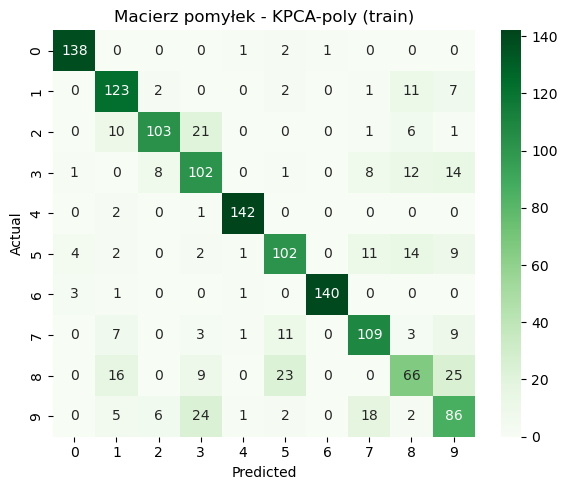

In [14]:
for name, (clf, Xtr, Xts) in models.items():
    y_pred_train = clf.predict(Xtr)
    y_pred_test = clf.predict(Xts)

    print(f"\n=== {name} ===")
    
    # Walidacja
    print("Test Classification Report:")
    print(classification_report(y_test, y_pred_test, digits=2))

    cm_test = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Macierz pomyłek - {name} (test)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Trening
    print("Train Classification Report:")
    print(classification_report(y_train, y_pred_train, digits=2))

    cm_train = confusion_matrix(y_train, y_pred_train)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Macierz pomyłek - {name} (train)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# 6. Wybierz $n=32, 16, 8, 4, 2$ dominujące cechy w każdej metodzie i wykonaj analizę w pkt. 5.


======= n_components = 32 =======


c:\Users\Jakub\anaconda3\Lib\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.85      0.97      0.91        36
           2       1.00      0.91      0.96        35
           3       0.97      0.89      0.93        37
           4       0.87      0.92      0.89        36
           5       0.95      0.97      0.96        37
           6       0.97      0.94      0.96        36
           7       0.92      0.97      0.95        36
           8       0.86      0.86      0.86        35
           9       0.94      0.86      0.90        36

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.93      0.93      0.93       360


=== Podsumowanie wyników ===
     Metoda   n  Train acc  Test acc
0       PCA  32   0.988866  0.955556
1       NMF  32   0.742519  0.738889
2        FA  32   0.986082  0.958333
3  KPCA-rbf  32   0.938065  0.930556

======= n_components = 16

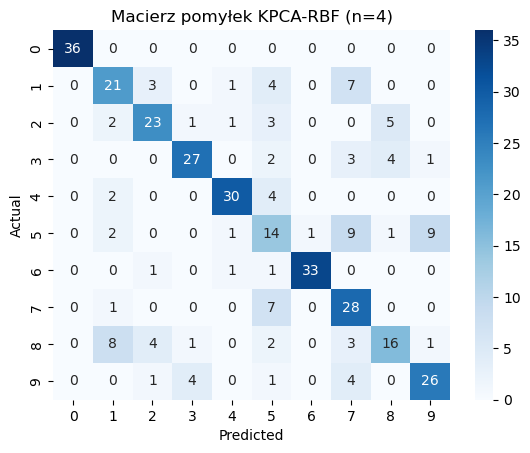


=== Podsumowanie wyników ===
      Metoda   n  Train acc  Test acc
0        PCA  32   0.988866  0.955556
1        NMF  32   0.742519  0.738889
2         FA  32   0.986082  0.958333
3   KPCA-rbf  32   0.938065  0.930556
4        PCA  16   0.963814  0.938889
5        NMF  16   0.804454  0.788889
6         FA  16   0.967989  0.938889
7   KPCA-rbf  16   0.912317  0.897222
8        PCA   8   0.883786  0.883333
9        NMF   8   0.768963  0.755556
10        FA   8   0.885177  0.883333
11  KPCA-rbf   8   0.834377  0.802778
12       PCA   4   0.798191  0.802778
13       NMF   4   0.645790  0.625000
14        FA   4   0.774530  0.780556
15  KPCA-rbf   4   0.703549  0.705556

======= n_components = 2 =======
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.58      0.72      0.64        36
           2       0.50      0.60      0.55        35
           3       0.71      0.73      0.72        37
           4       

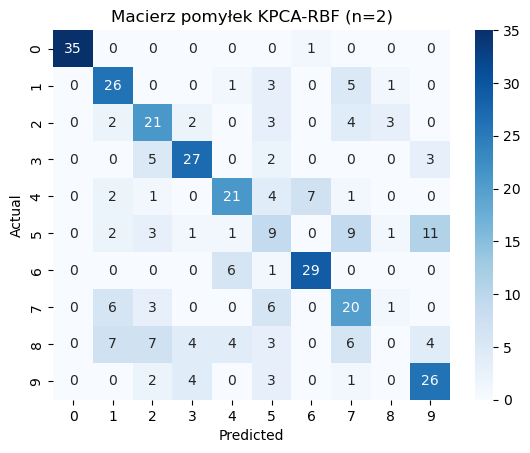


=== Podsumowanie wyników ===
      Metoda   n  Train acc  Test acc
0        PCA  32   0.988866  0.955556
1        NMF  32   0.742519  0.738889
2         FA  32   0.986082  0.958333
3   KPCA-rbf  32   0.938065  0.930556
4        PCA  16   0.963814  0.938889
5        NMF  16   0.804454  0.788889
6         FA  16   0.967989  0.938889
7   KPCA-rbf  16   0.912317  0.897222
8        PCA   8   0.883786  0.883333
9        NMF   8   0.768963  0.755556
10        FA   8   0.885177  0.883333
11  KPCA-rbf   8   0.834377  0.802778
12       PCA   4   0.798191  0.802778
13       NMF   4   0.645790  0.625000
14        FA   4   0.774530  0.780556
15  KPCA-rbf   4   0.703549  0.705556
16       PCA   2   0.549756  0.547222
17       NMF   2   0.321503  0.302778
18        FA   2   0.482255  0.475000
19  KPCA-rbf   2   0.558107  0.594444


In [15]:
n_components_list = [32, 16, 8, 4, 2]
methods = ['PCA', 'NMF', 'FA', 'KPCA-rbf']
summary = []

for n in n_components_list:
    print(f"\n======= n_components = {n} =======")
    
    # PCA
    pca = PCA(n_components=n, random_state=0)
    X_train_pca = pca.fit_transform(X_train_std)
    X_test_pca = pca.transform(X_test_std)
    
    clf_pca = LogisticRegression(random_state=0)
    clf_pca.fit(X_train_pca, y_train)
    acc_tr = accuracy_score(y_train, clf_pca.predict(X_train_pca))
    acc_te = accuracy_score(y_test, clf_pca.predict(X_test_pca))
    summary.append({'Metoda': 'PCA', 'n': n, 'Train acc': acc_tr, 'Test acc': acc_te})
    
    # NMF
    nmf = NMF(n_components=n, random_state=0)
    X_train_nmf_red = nmf.fit_transform(X_train_nmf)
    X_test_nmf_red = nmf.transform(X_test_nmf)
    
    clf_nmf = LogisticRegression(random_state=0)
    clf_nmf.fit(X_train_nmf_red, y_train)
    acc_tr = accuracy_score(y_train, clf_nmf.predict(X_train_nmf_red))
    acc_te = accuracy_score(y_test, clf_nmf.predict(X_test_nmf_red))
    summary.append({'Metoda': 'NMF', 'n': n, 'Train acc': acc_tr, 'Test acc': acc_te})
    
    # FA
    fa = FactorAnalysis(n_components=n, random_state=0)
    X_train_fa = fa.fit_transform(X_train_std)
    X_test_fa = fa.transform(X_test_std)
    
    clf_fa = LogisticRegression(random_state=0)
    clf_fa.fit(X_train_fa, y_train)
    acc_tr = accuracy_score(y_train, clf_fa.predict(X_train_fa))
    acc_te = accuracy_score(y_test, clf_fa.predict(X_test_fa))
    summary.append({'Metoda': 'FA', 'n': n, 'Train acc': acc_tr, 'Test acc': acc_te})
    
    # KPCA
    kpca = KernelPCA(n_components=n, kernel='rbf', gamma=0.03)
    X_train_kpca = kpca.fit_transform(X_train_std)
    X_test_kpca = kpca.transform(X_test_std)
    
    clf_kpca = LogisticRegression(random_state=0)
    clf_kpca.fit(X_train_kpca, y_train)
    acc_tr = accuracy_score(y_train, clf_kpca.predict(X_train_kpca))
    acc_te = accuracy_score(y_test, clf_kpca.predict(X_test_kpca))
    summary.append({'Metoda': 'KPCA-rbf', 'n': n, 'Train acc': acc_tr, 'Test acc': acc_te})

    
    print(classification_report(y_test, clf_kpca.predict(X_test_kpca)))
    if n in [2, 4]: # wyswietlanie macierzy pomyłek tylko dla n=2 i n=4 zeby uniknąć zbyt wielu wykresów
        cm = confusion_matrix(y_test, clf_kpca.predict(X_test_kpca))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Macierz pomyłek KPCA-RBF (n={n})')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    # summary
    summary_df = pd.DataFrame(summary)
    print("\n=== Podsumowanie wyników ===")
    print(summary_df)

# 7. Skomentuj uzyskane wyniki. Czy redukcja wymiarowości jest optymalnym rozwiązaniem w przypadku tego zbioru? Jeśli tak, to która? Jeśli żadna, to dlaczego?

[KOMENTARZ] Dla tego zbioru redukcja wymiarowości nie przynosi istotnych korzyści. Dane są stosunkowo małe (8x8 cech) i proste modele potrafią sobie z nimi rozsądnie radzić bez redukcji. Ponadto przy tak niewielkiej liczbie cech i dość subtelnych różnicach między klasami możemy utracić niezbędne do ich rozróżnienia dane (niektóre cyfry są dosyć podobne do siebie) nie zyskując istotnie na szybkości uczenia. Niektóre modele nie traciły istotnie na wynikach (najlepsze były PCA i FA), ale w tym przypadku prawdopodobnie nie warto z nich korzystać.

# 8. Zaproponuj usprawnienie metodologii wyżej (np. inną technikę selekcji cech)

[KOMENTARZ] Można za to rozważyć inne metody np. dodanie regularyzacji L1 do regresji logistycznej, również unikając przeuczenia i pośrednio ignorując mniej istotne cechy. Inną skuteczną metodą może być zastosowanie random forest, który również potrafi uchwycić ważność cech.

# Zadanie dodatkowe [0-4] pkt

1. [0-3 pkt] Dokonaj redukcji wymiarowości za pomocą trzech wybranych metod nieliniowych ze zbioru: t-SNE, UMAP, TriMAP, PaCMAP, a następnie użyj tak przetransformowanego zbioru w naszym problemie klasyfikacji cyfr
2. [0-1 pkt] Czy użycie tych zaawansowanych technik ma sens w tym przypadku?

In [16]:
import umap
import trimap
from sklearn.manifold import TSNE
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# 1. Dokonaj redukcji wielowymiarowości za pomocą t-SNE, UMAP i TriMAP

In [17]:
digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# t-SNE
X_train_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_train_std)
X_test_tsne = TSNE(n_components=2, random_state=0).fit_transform(X_test_std)

# UMAP
umap_model = umap.UMAP(n_components=2, random_state=0)
X_train_umap = umap_model.fit_transform(X_train_std)
X_test_umap = umap_model.transform(X_test_std)

# TriMap
X_full = np.vstack([X_train_std, X_test_std])
y_full = np.hstack([y_train, y_test])

X_full_trimap = trimap.TRIMAP(n_dims=2).fit_transform(X_full)

X_train_trimap = X_full_trimap[:len(X_train)]
X_test_trimap = X_full_trimap[len(X_train):]


# Ewaluacja modeli na zredukowanych danych
def evaluate(Xtr, Xts, ytr, yts, label):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, ytr)
    acc = accuracy_score(yts, clf.predict(Xts))
    print(f'{label} accuracy: {acc:.3f}')

evaluate(X_train_tsne, X_test_tsne, y_train, y_test, 't-SNE')
evaluate(X_train_umap, X_test_umap, y_train, y_test, 'UMAP')
evaluate(X_train_trimap, X_test_trimap, y_train, y_test, 'TriMap')

  File "c:\Users\Jakub\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Jakub\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Jakub\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Jakub\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


t-SNE accuracy: 0.128
UMAP accuracy: 0.103
TriMap accuracy: 0.083


# 2. Czy użycie tak zaawansowanych technik ma sens w tym przypadku?

[KOMENTARZ] UMAP i TriMap poradziły sobie dosyć dobrze, natomiast t-SNE bardzo słabo. Podobnie jak w punkcie 8. stwierdzam, że użycie redukcji wielowymiarowości dla tego zbioru danych nie jest zasadne.